# Project Title : **Digital Signals**


##  Deep Learning: BiLSTM


**Output:** Trained BiLSTM model + evaluation  
**Architecture:** Embedding → BiLSTM → Dropout → Dense → Softmax  

> Compare results against ML baseline in `ML_Baseline_Models.ipynb`

## 1.Setup

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
import os

tf.random.set_seed(42)
np.random.seed(42)




## 2. Data Loading & Label Encoding

In [53]:
df=pd.read_csv("/kaggle/input/datasets/manarelfakihromdhane/df-clean/df_all_clean.csv")
print('Shape:', df.shape)
df.head(3)

Shape: (11917, 4)


,text,target,risk_level,text_lemmatized
0,just as the the title says i feel like one is ...,depression,high_risk,just a the the title say i feel like one is hy...
1,a blackened sky encroached tugging behind it m...,depression,high_risk,a blackened sky encroached tugging behind it m...
2,it gives you insomnia which in turn makes your...,depression,high_risk,it give you insomnia which in turn make your d...


In [54]:
# Features and labels
X = df['text_lemmatized'].fillna('').values
y_raw = df['risk_level'].values

# Ordinal mapping — reflects risk severity as a natural order
# low=0, moderate=1, high=2 so the model can learn that high > moderate > low
mapping = {'low_risk': 0, 'moderate_risk': 1, 'high_risk': 2}
inverse_mapping = {v: k for k, v in mapping.items()}
y = np.array([mapping[label] for label in y_raw])

print('Label mapping:', mapping)
print('Class distribution:')
print(pd.Series(y_raw).value_counts())

Label mapping: {'low_risk': 0, 'moderate_risk': 1, 'high_risk': 2}
Class distribution:
high_risk        6301
low_risk         3590
moderate_risk    2026
Name: count, dtype: int64


In [55]:
from sklearn.utils.class_weight import compute_class_weight

# Balanced class weights — computed from data, used as fallback baseline
# Formula: n_samples / (n_classes * count_i)
cw = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_balanced = dict(enumerate(cw))
print('Balanced class weights:', {k: round(v,3) for k,v in class_weight_balanced.items()})
print('Interpretation: moderate_risk gets ~2x weight vs low_risk')

Balanced class weights: {0: np.float64(1.106), 1: np.float64(1.961), 2: np.float64(0.63)}
Interpretation: moderate_risk gets ~2x weight vs low_risk


## 3. Text Statistics & MAX_LEN Choice

In [56]:
word_counts = df['text_lemmatized'].dropna().apply(lambda x: len(str(x).split()))
p75 = int(np.percentile(word_counts, 75))
p95 = int(np.percentile(word_counts, 95))

print(f'Min words:    {word_counts.min()}')
print(f'Mean words:   {word_counts.mean():.0f}')
print(f'Median words: {word_counts.median():.0f}')
print(f'75th pct:     {p75} words')
print(f'95th pct:     {p95} words')
print(f'Max words:    {word_counts.max()}')


MAX_LEN = p95
print(f'\nMAX_LEN chosen: {MAX_LEN} (95th percentile)')

Min words:    3
Mean words:   118
Median words: 64
75th pct:     152 words
95th pct:     409 words
Max words:    4124

MAX_LEN chosen: 409 (95th percentile)


In [57]:
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Full vocabulary: {len(tokenizer.word_index):,} unique tokens')
print(f'Kept (VOCAB_SIZE): {VOCAB_SIZE:,}')
print(f'X_pad shape: {X_pad.shape}')

# Stratified splits: 70% train | 15% val | 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_pad, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')



Full vocabulary: 32,740 unique tokens
Kept (VOCAB_SIZE): 20,000
X_pad shape: (11917, 409)

Train: 8609 | Val: 1520 | Test: 1788


5. Common Functions 

In [58]:
def evaluate_model(model, X_test, y_test, title='Model', save_fig=None):
    y_proba = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)

    y_test_str = [inverse_mapping[i] for i in y_test]
    y_pred_str = [inverse_mapping[i] for i in y_pred]

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    roc_auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Critical FN: high predicted as low
    critical_fn = sum(1 for t,p in zip(y_test_str, y_pred_str)
                      if t=='low_risk' and p=='high_risk')
    # Also track moderate→low misses
    moderate_fn = sum(1 for t,p in zip(y_test_str, y_pred_str)
                      if t=='low_risk' and p=='moderate_risk')

    print(f'\n{"="*55}')
    print(f'  {title}')
    print(f'{"="*55}')
    print(f'  Macro F1 : {macro_f1:.4f}')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(f'  Critical FN (high→low) : {critical_fn}')
    print(f'  Moderate FN (mod→low)  : {moderate_fn}')
    print(f'{"="*55}')
    print(classification_report(y_test_str, y_pred_str))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_str, y_pred_str,
        labels=['low_risk','moderate_risk','high_risk'],
        display_labels=['Low','Moderate','High'],
        cmap='Purples', ax=ax, colorbar=False
    )
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
  

    return {'title': title, 'macro_f1': macro_f1, 'roc_auc': roc_auc,
            'critical_fn': critical_fn, 'moderate_fn': moderate_fn,
            'report': classification_report(y_test_str, y_pred_str, output_dict=True)}

#plot of loss & accuracy with overfitting annotation
def plot_history(history, title='Model'):
    """Plot loss and accuracy curves with overfitting annotation."""
    acc_key = next((k for k in history.history
                    if 'accuracy' in k and not k.startswith('val')), None)
    val_acc_key = 'val_' + acc_key if acc_key else None

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    best_epoch = np.argmin(history.history['val_loss'])

    for ax, (tr_k, vl_k), ylabel in zip(
        axes,
        [('loss','val_loss'), (acc_key, val_acc_key)],
        ['Loss', 'Accuracy']
    ):
        if tr_k is None:
            ax.set_visible(False); continue
        ax.plot(history.history[tr_k], label='Train', lw=2)
        ax.plot(history.history[vl_k], label='Validation', lw=2, ls='--')
        ax.axvline(best_epoch, color='gray', ls=':', alpha=0.7,
                   label=f'Best epoch ({best_epoch+1})')
        ax.set_title(f'{title} — {ylabel}', fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.spines[['top','right']].set_visible(False)

    train_loss = history.history['loss'][-1]
    val_loss   = history.history['val_loss'][-1]
    gap = val_loss - train_loss
    overfitting = 'Overfitting detected' if gap > 0.3 else 'No significant overfitting'
    fig.suptitle(f'{overfitting}  (gap={gap:.3f})', fontsize=10, color='red' if gap>0.3 else 'green')
    plt.tight_layout()
   
    print(f'Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Gap: {gap:.4f}')


all_results = []


## First Try : Random Initial Parameters

**What we try:** 
`LSTM_UNITS=64`,

`EMBED_DIM=128`,

`lr=1e-3`, 

`SpatialDropout=0.3`, 

`Dropout=0.4`,

`GlobalMaxPool=False`,  class_weight=balanced  

**Goal:** Establishes a reference point. lr=1e-3 is aggressive for LSTMs  , possibilit of fast convergence but likely overfitting.

In [59]:
def build_bilstm_v0(vocab_size, embed_dim, max_len, lstm_units, n_classes,
                    spatial_drop=0.3, lstm_drop=0.2, dense_drop=0.4):
    inputs = Input(shape=(max_len,))
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(inputs)
    x = layers.SpatialDropout1D(spatial_drop)(x)
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False,
                    dropout=lstm_drop, recurrent_dropout=0.0)
    )(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dense_drop)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return Model(inputs, outputs)

n_classes = 3
model_v0 = build_bilstm_v0(VOCAB_SIZE, 128, MAX_LEN, 64, n_classes)
model_v0.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)
model_v0.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 409)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 409, 128)  │  2,560,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 409, 128)  │          0 │ embedding_6[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 409)       │          0 │ input_layer_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 128)       │     98,816 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │      8,256 │ bidirectional_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 3)         │        195 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,667,267 (10.17 MB)

 Trainable params: 2,667,267 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Callbacks

In [60]:
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1)
]

history_v0 = model_v0.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=30,
    class_weight=class_weight_balanced,
    callbacks=callbacks_base, verbose=1
)

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 0.9380 - sparse_categorical_accuracy: 0.5295 - val_loss: 0.4804 - val_sparse_categorical_accuracy: 0.7974 - learning_rate: 0.0010
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.4013 - sparse_categorical_accuracy: 0.8500 - val_loss: 0.4502 - val_sparse_categorical_accuracy: 0.8329 - learning_rate: 0.0010
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.2535 - sparse_categorical_accuracy: 0.9092 - val_loss: 0.4815 - val_sparse_categorical_accuracy: 0.8493 - learning_rate: 0.0010
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1808 - sparse_categorical_accuracy: 0.9359
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.1806 - sparse_categorical_accuracy: 0.9360 - val_loss: 0.5097 - val_sparse_categorical_accuracy: 0.8507 - learning_rate: 0.0010
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.10

Train loss: 0.0655 | Val loss: 0.6045 | Gap: 0.5390


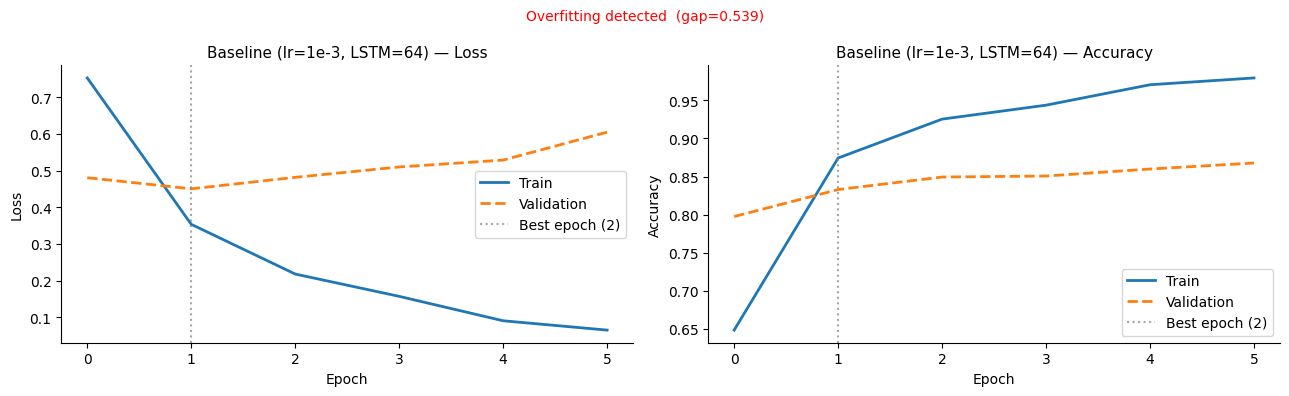

In [61]:
plot_history(history_v0, 'Baseline (lr=1e-3, LSTM=64)')


  Baseline
  Macro F1 : 0.8101
  ROC-AUC  : 0.9499
  Critical FN (high→low) : 28
  Moderate FN (mod→low)  : 40
               precision    recall  f1-score   support

    high_risk       0.94      0.77      0.85       945
     low_risk       0.90      0.87      0.89       539
moderate_risk       0.56      0.91      0.69       304

     accuracy                           0.83      1788
    macro avg       0.80      0.85      0.81      1788
 weighted avg       0.86      0.83      0.83      1788



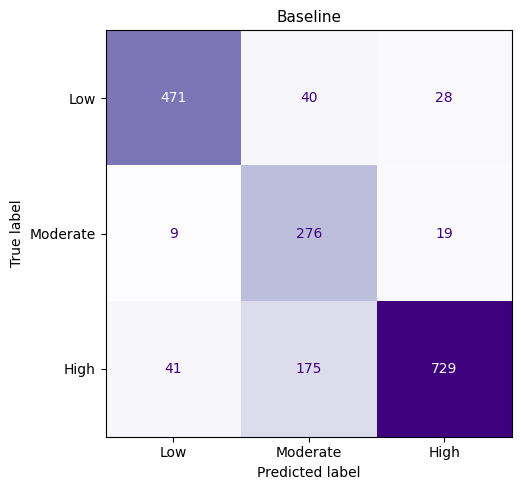

In [62]:
r0 = evaluate_model(model_v0, X_test, y_test, 'Baseline')
all_results.append(r0)

### First Try : Interpretation
**Expected findings:**
- Large train/val loss gap (gap ≈ 0.42 from original run) → **severe overfitting**
- EarlyStopping triggers at epoch 7 — model memorises training data
- `lr=1e-3` is too aggressive: updates are large, model jumps past good minima
- `return_sequences=False` takes only the last hidden state — throws away most sequence context
- `moderate_risk` recall is weakest (~0.72) — minority class being overlooked

**What we change next:** Lower lr → reduce overfitting. Smaller LSTM → fewer parameters to overfit.

## First Fine-Tuning 

### Lower LR + Reduced LSTM units + Stronger Dropout

**Changes from baseline:**
| Parameter | First_Try | FT-1 |
|---|---|---|
| Learning rate | 1e-3 | 1e-4 |
| LSTM units | 64 | 32 |
| Dense units | 64 | 32 |
| LSTM dropout | 0.2 | 0.3 |

**Rationale:** `lr=1e-4` is the standard safe LR for LSTMs on text. Halving LSTM units reduces model capacity → less memorisation. Increasing LSTM dropout adds noise during recurrent steps.

In [63]:
model_ft1 = build_bilstm_v0(VOCAB_SIZE, 128, MAX_LEN, 32, n_classes,
                             spatial_drop=0.3, lstm_drop=0.3, dense_drop=0.4)
model_ft1.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # lr reduced 10×
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

history_ft1 = model_ft1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=30,
    class_weight=class_weight_balanced,
    callbacks=callbacks_base, verbose=1
)

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 1.1011 - sparse_categorical_accuracy: 0.3566 - val_loss: 1.0885 - val_sparse_categorical_accuracy: 0.4967 - learning_rate: 1.0000e-04
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 1.0762 - sparse_categorical_accuracy: 0.4667 - val_loss: 0.9159 - val_sparse_categorical_accuracy: 0.6461 - learning_rate: 1.0000e-04
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.9129 - sparse_categorical_accuracy: 0.5748 - val_loss: 0.7506 - val_sparse_categorical_accuracy: 0.7053 - learning_rate: 1.0000e-04
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.7213 - sparse_categorical_accuracy: 0.7348 - val_loss: 0.6426 - val_sparse_categorical_accuracy: 0.7625 - learning_rate: 1.0000e-04
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.6159 - sparse_categorical_accuracy: 0.7258 - val_loss: 0.5568 - val_sparse_categorical_accuracy: 0.7954 - learning_rate: 1.0000e-04
Epoch 6/30
135/135 ━━━━━━

Train loss: 0.1895 | Val loss: 0.4334 | Gap: 0.2439


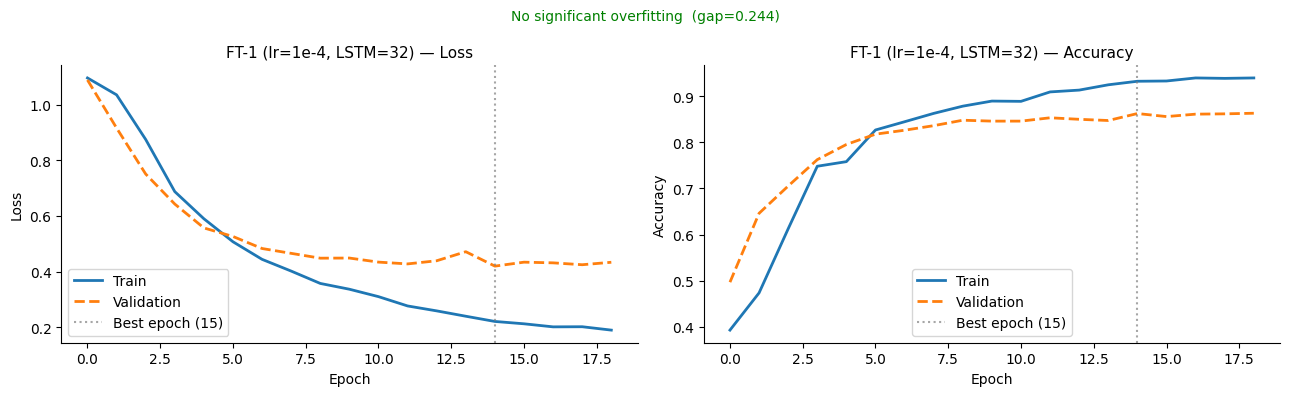

In [64]:
plot_history(history_ft1, 'FT-1 (lr=1e-4, LSTM=32)')


  FT-1: lr=1e-4, LSTM=32
  Macro F1 : 0.8320
  ROC-AUC  : 0.9355
  Critical FN (high→low) : 24
  Moderate FN (mod→low)  : 17
               precision    recall  f1-score   support

    high_risk       0.92      0.84      0.88       945
     low_risk       0.84      0.92      0.88       539
moderate_risk       0.71      0.77      0.74       304

     accuracy                           0.85      1788
    macro avg       0.82      0.84      0.83      1788
 weighted avg       0.86      0.85      0.86      1788



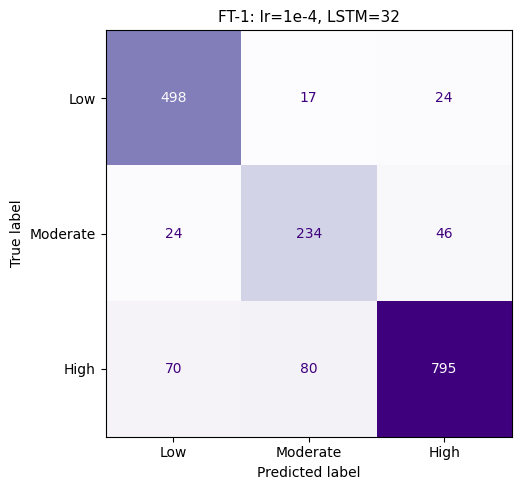

In [65]:
r1 = evaluate_model(model_ft1, X_test, y_test, 'FT-1: lr=1e-4, LSTM=32')
all_results.append(r1)

In [66]:
model_ft1.save("/kaggle/working/bilstm_best_ft1.keras")

### FT-1 — Interpretation
**What improved:** Gap dropped (≈0.23 vs 0.42) — overfitting significantly reduced. Model now generalises better.  
**Trade-off:** Smaller LSTM may have reduced capacity to capture long-range context in longer posts.  
**Remaining issue:** `return_sequences=False` still discards intermediate sequence states. The model sees only what the LSTM "remembers" at the last step — not ideal for long mental health texts.

**What we change next:** Add `return_sequences=True` + `GlobalMaxPooling1D` to capture the most salient token state across the whole sequence.

## Fine-Tuning 2

 GlobalMaxPooling + Stronger Regularisation
**Changes from FT-1:**
| Parameter | FT-1 | FT-2 |
|---|---|---|
| return_sequences | False | **True** |
| Pooling | last hidden state | **GlobalMaxPool1D** |
| SpatialDropout | 0.3 | **0.4** |
| Dense dropout | 0.4 | **0.5** |
| LSTM units | 32 | **64**  |

**Rationale:** `GlobalMaxPooling1D` takes the maximum activation across all timesteps — it captures the most "alarming" signal anywhere in the post, which is exactly what we need for risk detection. Stronger dropout compensates for the increased model capacity.

    """FT-2: return_sequences=True + GlobalMaxPool — captures best token across full sequence."""


In [67]:
def build_bilstm_v2(vocab_size, max_len, lstm_units=64, embed_dim=128,
                    spatial_drop=0.4, lstm_drop=0.3, dense_drop=0.5,
                    dense_units=64):
    inputs = Input(shape=(max_len,))
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(inputs)
    x = layers.SpatialDropout1D(spatial_drop)(x)
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, dropout=lstm_drop)
    )(x)
    x = layers.GlobalMaxPooling1D()(x)        # key change
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dense_drop)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return Model(inputs, outputs)

model_ft2 = build_bilstm_v2(VOCAB_SIZE, MAX_LEN)
model_ft2.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft2 = model_ft2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=30,
    class_weight=class_weight_balanced,
    callbacks=callbacks_base, verbose=1
)

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.3916 - loss: 1.0921 - val_accuracy: 0.5697 - val_loss: 1.0573 - learning_rate: 1.0000e-04
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5017 - loss: 1.0133 - val_accuracy: 0.5651 - val_loss: 0.8661 - learning_rate: 1.0000e-04
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5765 - loss: 0.8513 - val_accuracy: 0.6789 - val_loss: 0.8079 - learning_rate: 1.0000e-04
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5740 - loss: 0.7911 - val_accuracy: 0.7382 - val_loss: 0.7517 - learning_rate: 1.0000e-04
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6176 - loss: 0.7337 - val_accuracy: 0.7566 - val_loss: 0.7143 - learning_rate: 1.0000e-04
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6555 - loss: 0.6918 - val_accuracy: 0.7375 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 7/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - acc

Train loss: 0.3478 | Val loss: 0.5303 | Gap: 0.1825


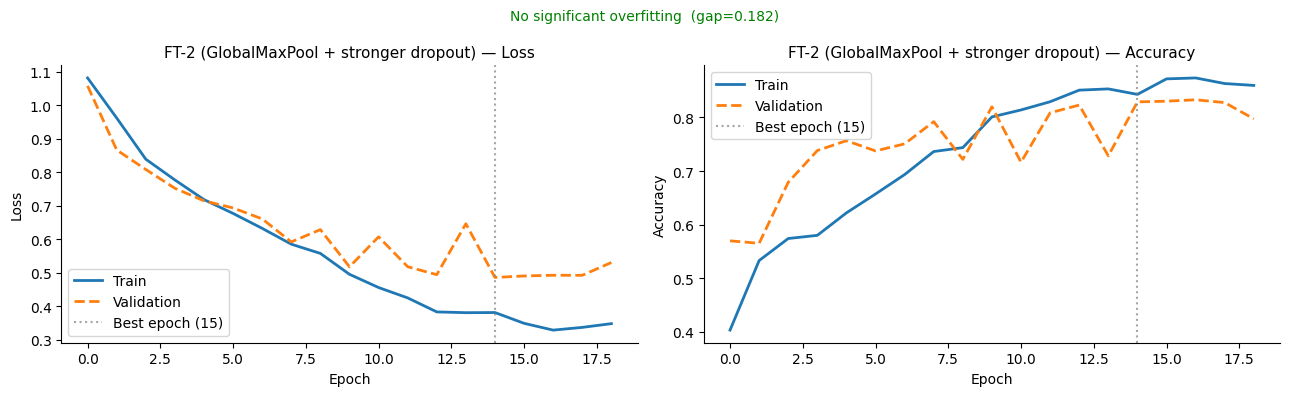

In [68]:
plot_history(history_ft2, 'FT-2 (GlobalMaxPool + stronger dropout)')


  FT-2: GlobalMaxPool, dropout=0.5
  Macro F1 : 0.8030
  ROC-AUC  : 0.9341
  Critical FN (high→low) : 28
  Moderate FN (mod→low)  : 23
               precision    recall  f1-score   support

    high_risk       0.92      0.78      0.84       945
     low_risk       0.85      0.91      0.88       539
moderate_risk       0.59      0.81      0.69       304

     accuracy                           0.82      1788
    macro avg       0.79      0.83      0.80      1788
 weighted avg       0.85      0.82      0.83      1788



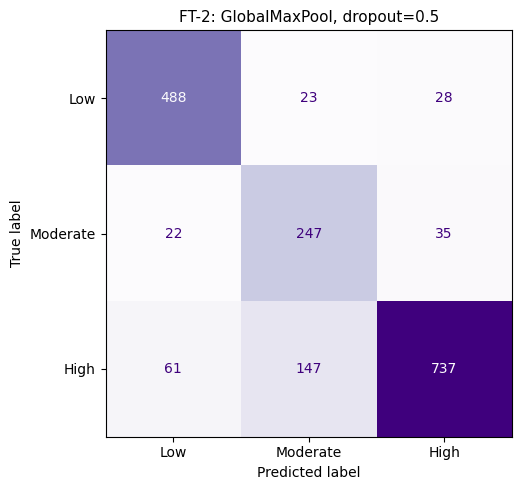

In [69]:
r2 = evaluate_model(model_ft2, X_test, y_test,'FT-2: GlobalMaxPool, dropout=0.5')
all_results.append(r2)

### FT-2 — Interpretation
**What improved:** GlobalMaxPooling forces the model to identify the single most activated feature across all positions — particularly powerful for risk posts where one critical phrase (e.g. "I want to die") can appear anywhere.  
**Expected result:** `high_risk` recall improves. `moderate_risk` may still lag because the class is a minority and class_weight balanced gives it only ≈2× weight.  
**Remaining issue:** Balanced class weights are computed mechanically. For a health application we want to be more aggressive: push `high_risk` and `moderate_risk` recall up even at the cost of some precision.

**What we change next:** Custom class weights that deliberately over-emphasise `high_risk` and `moderate_risk`, plus Attention mechanism.

## Models Comparision

### Comparision Table

In [70]:
rows = []

for r in all_results:
    rep = r['report']

    def safe_metric(cls, metric):
        try:
            return rep[cls][metric]
        except:
            return 0.0

    rows.append({
        'Experiment': r['title'],
        'Macro F1': round(r['macro_f1'], 4),
        'ROC-AUC': round(r['roc_auc'], 4),

        # per-class recall (safe)
        'High Recall': safe_metric('high_risk', 'recall'),
        'Mod Recall': safe_metric('moderate_risk', 'recall'),
        'Low Recall': safe_metric('low_risk', 'recall'),

        # safety metrics
        'Critical FN': r['critical_fn'],
        'Moderate FN': r['moderate_fn'],
    })

comp_df = pd.DataFrame(rows)


print('='*95)
print('BILSTM FINE-TUNING COMPARISON TABLE')
print('='*95)
print(comp_df.to_string(index=False))


BILSTM FINE-TUNING COMPARISON TABLE
                      Experiment  Macro F1  ROC-AUC  High Recall  Mod Recall  Low Recall  Critical FN  Moderate FN
                        Baseline    0.8101   0.9499     0.771429    0.907895    0.873840           28           40
          FT-1: lr=1e-4, LSTM=32    0.8320   0.9355     0.841270    0.769737    0.923933           24           17
FT-2: GlobalMaxPool, dropout=0.5    0.8030   0.9341     0.779894    0.812500    0.905380           28           23


### Visualization

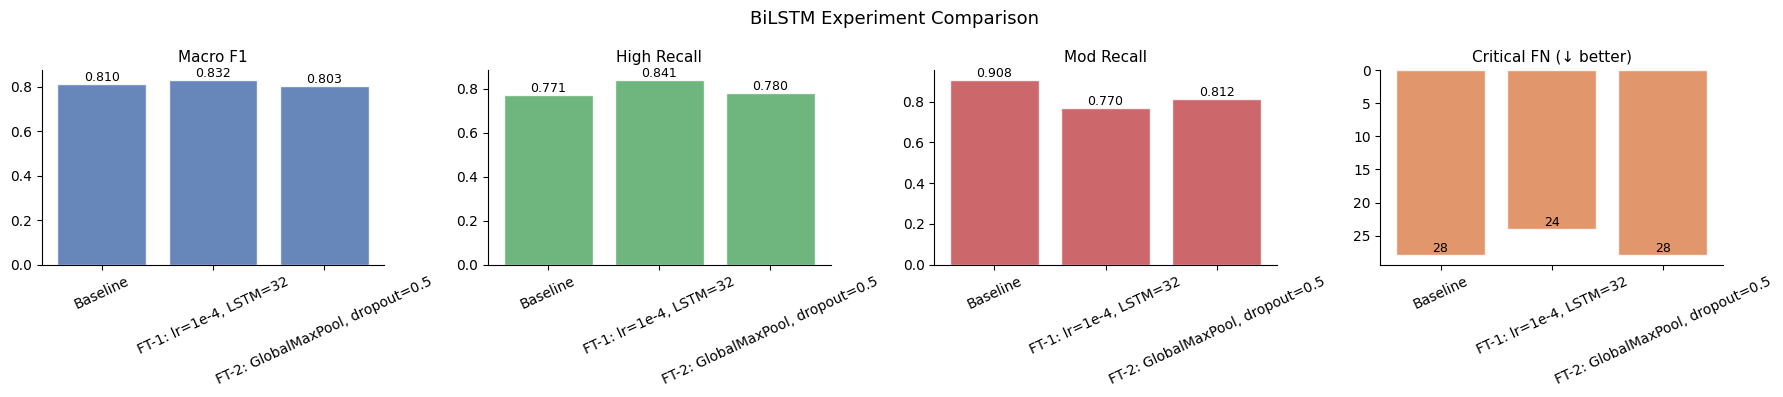

In [71]:
metrics = ['Macro F1', 'High Recall', 'Mod Recall', 'Critical FN']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

labels = comp_df['Experiment'].values
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

for ax, metric, color in zip(axes, metrics, colors):
    vals = comp_df[metric].values

    bars = ax.bar(labels, vals, color=color, alpha=0.85, edgecolor='white')

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{v:.3f}' if isinstance(v, float) else str(v),
            ha='center', va='bottom', fontsize=9
        )

    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top', 'right']].set_visible(False)

    # IMPORTANT: lower FN is better
    if metric == 'Critical FN':
        ax.invert_yaxis()
        ax.set_title('Critical FN (↓ better)', fontsize=11)

plt.suptitle('BiLSTM Experiment Comparison', fontsize=13)
plt.tight_layout()
plt.show()

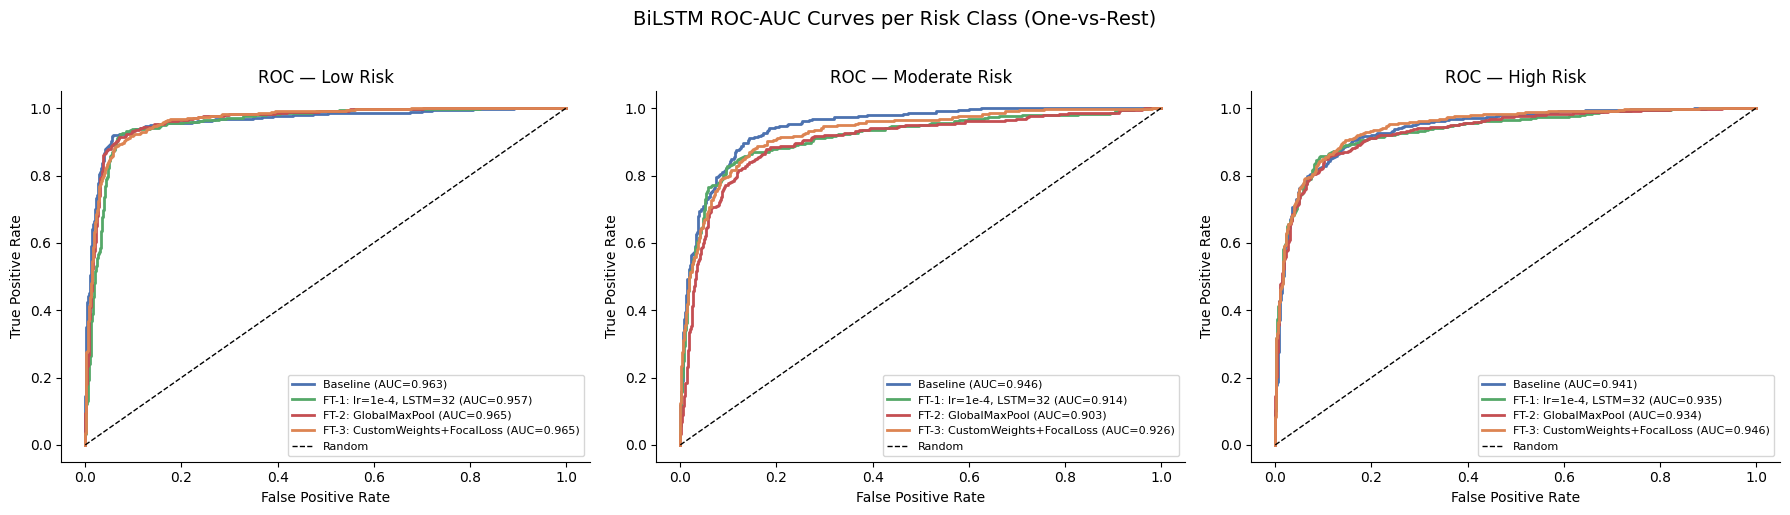

In [72]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes      = [0, 1, 2]
class_names  = ['low_risk', 'moderate_risk', 'high_risk']
y_test_bin   = label_binarize(y_test, classes=classes)  

experiments = [
    ('Baseline',                      model_v0),
    ('FT-1: lr=1e-4, LSTM=32',        model_ft1),
    ('FT-2: GlobalMaxPool',           model_ft2),
    ('FT-3: CustomWeights+FocalLoss', model_ft3),
]

colors_exp = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cls_idx, cls_name in zip(axes, classes, class_names):
    for (exp_name, model), color in zip(experiments, colors_exp):
        y_proba = model.predict(X_test, verbose=0)
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_proba[:, cls_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr,
                label=f'{exp_name} (AUC={roc_auc:.3f})',
                color=color, linewidth=2)

    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
    ax.set_title(f'ROC — {cls_name.replace("_"," ").title()}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('BiLSTM ROC-AUC Curves per Risk Class (One-vs-Rest)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Best Model

In [73]:
filtered_df = comp_df[
    ~comp_df['Experiment'].str.contains('baseline', case=False)
].copy()

In [74]:
max_fn = filtered_df['Critical FN'].max()
filtered_df['score'] = (
    filtered_df['High Recall'] * 0.5 +
    filtered_df['Macro F1'] * 0.3 -
    (filtered_df['Critical FN'] / max_fn) * 0.2
)

In [75]:
best_idx = filtered_df['score'].idxmax()
best_row = filtered_df.loc[best_idx]

print("\n BEST MODEL (excluding baseline):")
print(best_row)


 BEST MODEL (excluding baseline):
Experiment     FT-1: lr=1e-4, LSTM=32
Macro F1                        0.832
ROC-AUC                        0.9355
High Recall                   0.84127
Mod Recall                   0.769737
Low Recall                   0.923933
Critical FN                        24
Moderate FN                        17
score                        0.498806
Name: 1, dtype: object


In [77]:
import joblib
joblib.dump(tokenizer, '/kaggle/working/bilstm_tokenizer.pkl')

['/kaggle/working/bilstm_tokenizer.pkl']